# Analisis de tendencias (punto 3)

Este notebook obtiene la tabla `compras` desde PostgreSQL y responde los cuatro incisos del punto 3 del enunciado:

- **3.a** Meses con mayores y menores ventas.
- **3.b** Navegador (canal) mas preferido y menos popular.
- **3.c** Total de ventas pagadas en efectivo o contra entrega.
- **3.d** Meses donde se usaron mas boletines y mas vales.

Los mismos calculos estan expuestos al agente conversacional como herramientas MCP (`obtener_ventas_por_mes`, `obtener_navegador_preferido`, `obtener_ventas_efectivo_contra_entrega`, `obtener_boletines_vales_por_mes`), de modo que el notebook y el chat siempre muestran el mismo resultado.

## Criterio de calculo

- El **total de ventas** de un mes se calcula sumando `monto_compra` de todas las compras de `compras` cuyo `fecha_compra` cae en ese mes.
- El **navegador preferido** se calcula contando filas de `compras` por valor de `navegador` (0 = Tienda Fisica, 1-4 = canales web); se incluye la tienda fisica porque el enunciado la define como un valor valido de esa misma columna.
- **Efectivo / contra entrega** corresponde unicamente a `metodo_pago = 0`, segun la aclaracion del esquema de base de datos.
- El uso de **boletines** y **vales** se cuenta por separado (`boletin = TRUE`, `vale = TRUE`) y se agrupa por mes; una compra puede contar para ambos si uso boletin y vale a la vez.

## Preparacion del entorno

En Google Colab, agregue `DB_HOST`, `DB_PORT`, `DB_NAME`, `DB_USER` y `DB_PASSWORD` en el panel **Secrets** y habilite su acceso. La siguiente celda instala las dependencias, clona el repositorio y crea un archivo `.env` temporal sin mostrar las credenciales. En Jupyter local se utiliza el repositorio y el `.env` existentes.

In [1]:
import os
import subprocess
import sys
from pathlib import Path

EN_COLAB = 'google.colab' in sys.modules
REPOSITORIO = 'https://github.com/AngelMendoz/SOG2-2S26_grupo8.git'

if EN_COLAB:
    subprocess.run(
        [sys.executable, '-m', 'pip', 'install', '-q',
         'numpy>=1.26', 'pandas>=2.2', 'psycopg2-binary>=2.9',
         'python-dotenv>=1.0', 'SQLAlchemy>=2.0', 'matplotlib>=3.8'],
        check=True,
    )
    raiz_repositorio = Path('/content/SOG2-2S26_grupo8')
    if not raiz_repositorio.is_dir():
        subprocess.run(['git', 'clone', '--depth', '1', REPOSITORIO, str(raiz_repositorio)], check=True)
    RAIZ_PRACTICA = raiz_repositorio / 'Practica_1'

    from google.colab import userdata

    nombres_secretos = ('DB_HOST', 'DB_PORT', 'DB_NAME', 'DB_USER', 'DB_PASSWORD')
    secretos = {}
    for nombre in nombres_secretos:
        try:
            valor = userdata.get(nombre)
        except Exception as error:
            raise ValueError(f'Falta habilitar el secreto {nombre} en Google Colab.') from error
        if not valor:
            raise ValueError(f'El secreto {nombre} esta vacio en Google Colab.')
        secretos[nombre] = valor
    (RAIZ_PRACTICA / '.env').write_text(
        ''.join(f'{nombre}={valor}\n' for nombre, valor in secretos.items()),
        encoding='utf-8',
    )
else:
    RAIZ_PRACTICA = Path.cwd().resolve()
    if not (RAIZ_PRACTICA / 'app').is_dir():
        RAIZ_PRACTICA = RAIZ_PRACTICA.parent

if not (RAIZ_PRACTICA / 'app').is_dir():
    raise FileNotFoundError('No se encontro la carpeta Practica_1.')

print(f'Entorno listo: {RAIZ_PRACTICA}')

Entorno listo: /Users/gio/Desktop/lab_geren2/practica_1/SOG2-2S26_grupo8/Practica_1


## Obtencion de datos

Se reutiliza `crear_motor` y `obtener_datos` del punto 2 (misma transaccion `REPEATABLE READ` de solo lectura) para traer `compras`. El punto 3 no necesita la tabla `clientes`.

In [2]:
import sys
from pathlib import Path

from IPython.display import display

if str(RAIZ_PRACTICA) not in sys.path:
    sys.path.insert(0, str(RAIZ_PRACTICA))

from app.analisis.punto_02 import crear_motor, obtener_datos
from app.analisis.punto_03 import (
    boletines_vales_por_mes,
    navegador_preferido,
    ventas_efectivo_contra_entrega,
    ventas_por_mes,
)

DIRECTORIO_RESULTADOS = RAIZ_PRACTICA / '03-Analisis-tendencia' / 'resultados'

motor = crear_motor(RAIZ_PRACTICA / '.env')
clientes, compras, control = obtener_datos(motor)

print(f"Compras obtenidas: {len(compras):,}")
print(f"Transaccion de solo lectura: {control['solo_lectura']}")
print(f"Rango de fechas: {compras['fecha_compra'].min().date()} a {compras['fecha_compra'].max().date()}")

Compras obtenidas: 6,500
Transaccion de solo lectura: on
Rango de fechas: 2021-01-01 a 2021-12-31


## 3.a Meses con mayores y menores ventas

Se agrupa `compras` por el mes de `fecha_compra` y se suma `monto_compra`. La tabla incluye tambien el numero de compras y la venta promedio de cada mes como contexto adicional.

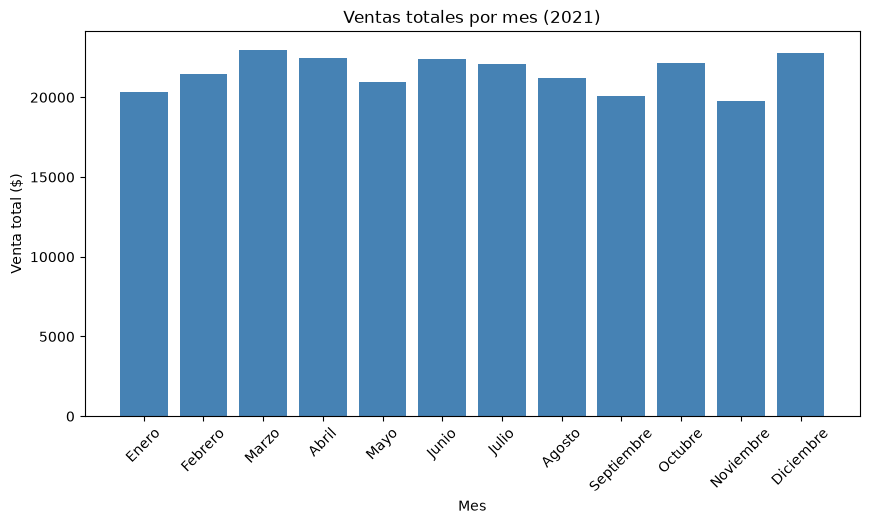

,mes_nombre,total_ventas,n_compras,venta_promedio
0,Enero,"$20,315.90",520,$39.07
1,Febrero,"$21,438.81",545,$39.34
2,Marzo,"$22,994.34",569,$40.41
3,Abril,"$22,468.97",557,$40.34
4,Mayo,"$20,944.68",530,$39.52
5,Junio,"$22,393.60",543,$41.24
6,Julio,"$22,085.58",565,$39.09
7,Agosto,"$21,190.51",530,$39.98
8,Septiembre,"$20,074.83",508,$39.52
9,Octubre,"$22,151.33",563,$39.35


Mes con mayor venta: Marzo ($22,994.34)
Mes con menor venta: Noviembre ($19,779.24)


In [3]:
resultado_meses = ventas_por_mes(compras, directorio_resultados=DIRECTORIO_RESULTADOS)

tabla_meses = resultado_meses['tabla_mensual'][['mes_nombre', 'total_ventas', 'n_compras', 'venta_promedio']]
display(tabla_meses.style.format({'total_ventas': '${:,.2f}', 'venta_promedio': '${:,.2f}'}))

print(f"Mes con mayor venta: {resultado_meses['mes_mayor_venta']} (${resultado_meses['mes_mayor_venta_total']:,.2f})")
print(f"Mes con menor venta: {resultado_meses['mes_menor_venta']} (${resultado_meses['mes_menor_venta_total']:,.2f})")

## 3.b Navegador mas preferido y menos popular

Se cuentan las compras por valor de `navegador` (0 = Tienda Fisica, 1-4 = canales web) y se ordenan de mayor a menor frecuencia.

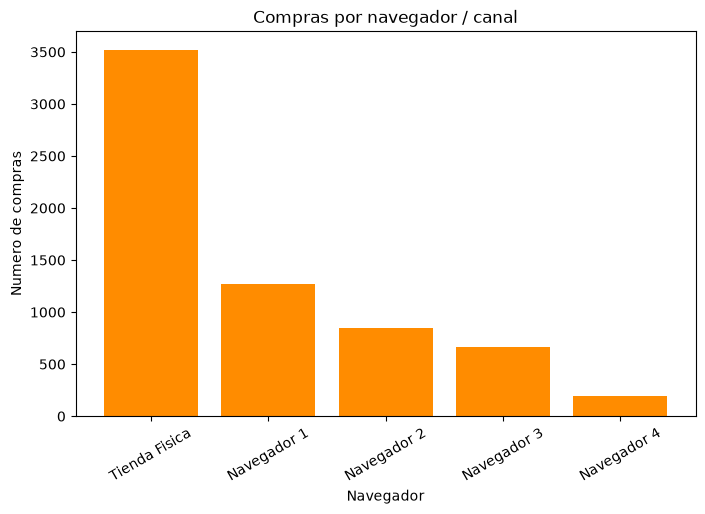

,navegador,n_compras,navegador_desc
0,0,3523,Tienda Fisica
1,1,1273,Navegador 1
2,2,847,Navegador 2
3,3,660,Navegador 3
4,4,197,Navegador 4


Mas preferido: Tienda Fisica (3523 compras)
Menos popular: Navegador 4 (197 compras)


In [4]:
resultado_navegador = navegador_preferido(compras, directorio_resultados=DIRECTORIO_RESULTADOS)

display(resultado_navegador['tabla_navegadores'])

print(f"Mas preferido: {resultado_navegador['navegador_mas_preferido']} "
      f"({resultado_navegador['navegador_mas_preferido_compras']} compras)")
print(f"Menos popular: {resultado_navegador['navegador_menos_popular']} "
      f"({resultado_navegador['navegador_menos_popular_compras']} compras)")

## 3.c Ventas pagadas en efectivo o contra entrega

`metodo_pago = 0` agrupa efectivo y contra entrega segun el esquema de la base de datos. Se calcula el total, el numero de compras y el porcentaje que representa sobre el total general de ventas.

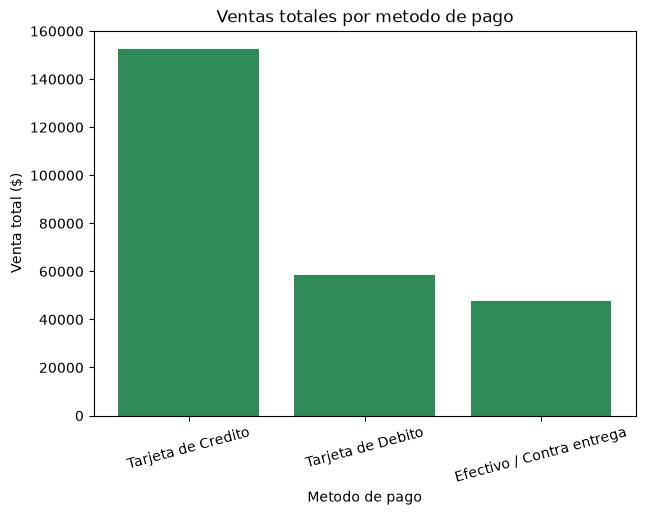

,metodo_desc,total_ventas,n_compras
0,Tarjeta de Credito,"$152,601.47",3827
1,Tarjeta de Debito,"$58,548.74",1466
2,Efectivo / Contra entrega,"$47,465.64",1207


Total efectivo/contra entrega: $47,465.64
Compras en efectivo/contra entrega: 1,207
Porcentaje del total de ventas: 18.35%


In [5]:
resultado_metodo_pago = ventas_efectivo_contra_entrega(compras, directorio_resultados=DIRECTORIO_RESULTADOS)

display(resultado_metodo_pago['tabla_metodo_pago'].style.format({'total_ventas': '${:,.2f}'}))

print(f"Total efectivo/contra entrega: ${resultado_metodo_pago['total_efectivo_contra_entrega']:,.2f}")
print(f"Compras en efectivo/contra entrega: {resultado_metodo_pago['n_compras_efectivo_contra_entrega']:,}")
print(f"Porcentaje del total de ventas: {resultado_metodo_pago['porcentaje_del_total']:.2f}%")

## 3.d Meses con mas uso de boletines y de vales

Se cuentan por separado las compras con `boletin = TRUE` y con `vale = TRUE`, agrupadas por mes de `fecha_compra`.

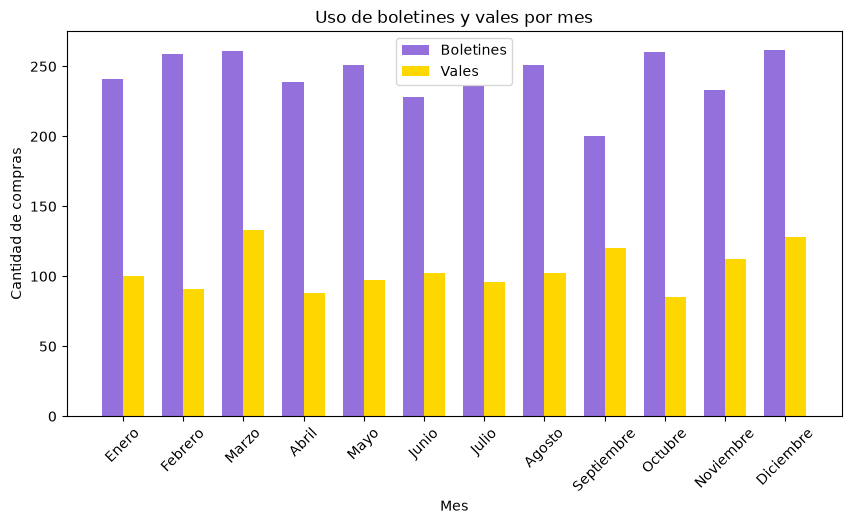

,mes_nombre,n_boletines,n_vales
0,Enero,241,100
1,Febrero,259,91
2,Marzo,261,133
3,Abril,239,88
4,Mayo,251,97
5,Junio,228,102
6,Julio,236,96
7,Agosto,251,102
8,Septiembre,200,120
9,Octubre,260,85


Mes con mas boletines: Diciembre (262)
Mes con mas vales: Marzo (133)


In [6]:
resultado_bv = boletines_vales_por_mes(compras, directorio_resultados=DIRECTORIO_RESULTADOS)

display(resultado_bv['tabla_mensual'][['mes_nombre', 'n_boletines', 'n_vales']])

print(f"Mes con mas boletines: {resultado_bv['mes_mas_boletines']} ({resultado_bv['mes_mas_boletines_cantidad']})")
print(f"Mes con mas vales: {resultado_bv['mes_mas_vales']} ({resultado_bv['mes_mas_vales_cantidad']})")

## Resumen del punto 3

Las cuatro celdas anteriores generan tambien un `.png` cada una dentro de `03-Analisis-tendencia/resultados/` (`ventas_por_mes.png`, `navegador_preferido.png`, `ventas_metodo_pago.png` y `boletines_vales_por_mes.png`), listos para incluir en el informe.

In [7]:
print('--- Resumen ejecutivo del punto 3 ---')
print(f"1. Mes con mayor venta: {resultado_meses['mes_mayor_venta']} | "
      f"Mes con menor venta: {resultado_meses['mes_menor_venta']}")
print(f"2. Navegador mas preferido: {resultado_navegador['navegador_mas_preferido']} | "
      f"Menos popular: {resultado_navegador['navegador_menos_popular']}")
print(f"3. Ventas en efectivo/contra entrega: ${resultado_metodo_pago['total_efectivo_contra_entrega']:,.2f} "
      f"({resultado_metodo_pago['porcentaje_del_total']:.2f}% del total)")
print(f"4. Mes con mas boletines: {resultado_bv['mes_mas_boletines']} | "
      f"Mes con mas vales: {resultado_bv['mes_mas_vales']}")

--- Resumen ejecutivo del punto 3 ---
1. Mes con mayor venta: Marzo | Mes con menor venta: Noviembre
2. Navegador mas preferido: Tienda Fisica | Menos popular: Navegador 4
3. Ventas en efectivo/contra entrega: $47,465.64 (18.35% del total)
4. Mes con mas boletines: Diciembre | Mes con mas vales: Marzo
